# 04 — Best-Spec Dynamics + Secondary Test

Time series of the best `(fast, w_fast)` selected each year under both
protocols. Pre-registered secondary test:

```
H0: P(continuation) = P(reversal) = P(neutral) = 1/3
H1: at least one differs
```

Plus exploratory regression on contemporaneous covariates (NBER, dispersion,
market vol).


In [1]:
import sys, os
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trend import (fetch_ff49, fetch_tbill_1m, grid_backtest, walkforward_oos,
                    best_spec_sign_test, multinomial_chi2_test,
                    plot_best_spec_ts, plot_w_fast_histogram)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})
RESULTS = "../results"


In [2]:
# Reload spec histories from primary notebook (or re-run if missing)
hist_files = {
    "Expanding":  f"{RESULTS}/02_spec_history_expanding.csv",
    "Rolling 30y": f"{RESULTS}/02_spec_history_rolling30y.csv",
}
if all(os.path.exists(p) for p in hist_files.values()):
    histories = {k: pd.read_csv(v, index_col="decision_date", parse_dates=True)
                 for k, v in hist_files.items()}
    print("Loaded spec histories from 02 outputs.")
else:
    print("Re-running walk-forward...")
    ff49 = fetch_ff49(cache_dir="../data")
    rf   = fetch_tbill_1m(cache_dir="../data")
    grid = grid_backtest(ff49, rf, tcost_bps=20.0)
    _, hist_exp = walkforward_oos(grid, warmup_end="1976-06-30", train_window="expanding")
    _, hist_r30 = walkforward_oos(grid, warmup_end="1976-06-30", train_window=30)
    histories = {"Expanding": hist_exp, "Rolling 30y": hist_r30}


Loaded spec histories from 02 outputs.


## 1. Best-spec time series

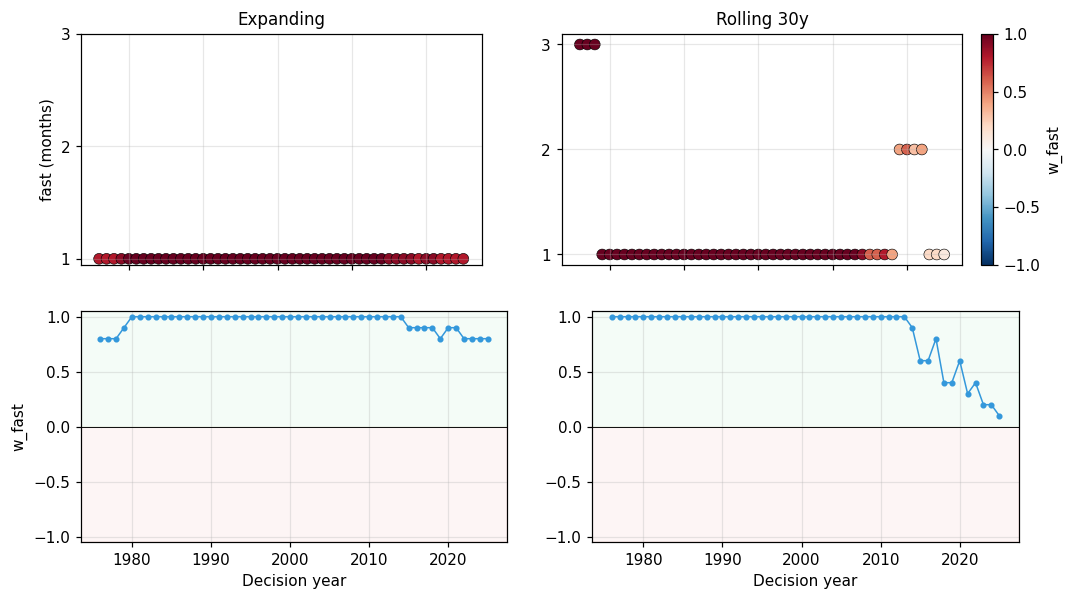

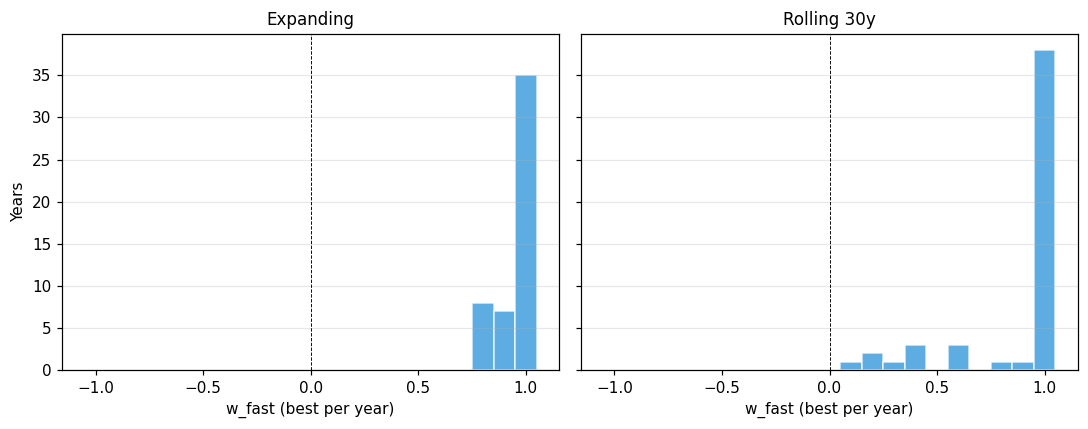

In [3]:
fig, _ = plot_best_spec_ts(histories)
fig.savefig(f"{RESULTS}/04_best_spec_ts.png", dpi=120, bbox_inches="tight")
plt.show()

fig, _ = plot_w_fast_histogram(histories)
fig.savefig(f"{RESULTS}/04_wfast_hist.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Secondary test — multinomial χ² (continuation / reversal / neutral)

In [4]:
rows = []
for name, h in histories.items():
    out = best_spec_sign_test(h)
    rows.append({"protocol": name,
                  "n_continuation": int(out["observed"][0]),
                  "n_reversal":     int(out["observed"][1]),
                  "n_neutral":      int(out["observed"][2]),
                  "chi2": out["chi2"],
                  "df": out["df"],
                  "p_value": out["p_value"]})
df_sec = pd.DataFrame(rows)
display(df_sec.round(4))
df_sec.to_csv(f"{RESULTS}/04_secondary_test.csv", index=False)


,protocol,n_continuation,n_reversal,n_neutral,chi2,df,p_value
0,Expanding,50,0,0,100.0,2,0.0
1,Rolling 30y,50,0,0,100.0,2,0.0


## 3. Tertiary descriptive — autocorrelation of selection

In [5]:
for name, h in histories.items():
    print(f"\n{name}:")
    print(f"  fast distribution:        {dict(h['fast'].value_counts().sort_index())}")
    print(f"  w_fast: mean={h['w_fast'].mean():+.3f}, median={h['w_fast'].median():+.2f}, std={h['w_fast'].std():.3f}")
    if h["w_fast"].std() > 0:
        # AR(1) autocorrelation
        ac1 = h["w_fast"].autocorr(lag=1)
        ac3 = h["w_fast"].autocorr(lag=3) if len(h) > 4 else np.nan
        print(f"  w_fast autocorr lag-1:    {ac1:.3f}")
        print(f"  w_fast autocorr lag-3:    {ac3:.3f}")



Expanding:
  fast distribution:        {1: 50}
  w_fast: mean=+0.954, median=+1.00, std=0.076
  w_fast autocorr lag-1:    0.885
  w_fast autocorr lag-3:    0.616

Rolling 30y:
  fast distribution:        {1: 43, 2: 4, 3: 3}
  w_fast: mean=+0.870, median=+1.00, std=0.261
  w_fast autocorr lag-1:    0.926
  w_fast autocorr lag-3:    0.925


## 4. Exploratory regression (labeled exploratory)

Best `(fast, w_fast)` regressed on contemporaneous covariates. Note: this
section is labeled exploratory; no formal inferential claims.

Available covariates without external data fetch:
- Cross-sectional dispersion of FF49 returns over the past year
- Aggregate market vol (FF Mkt-RF realized vol, past 12 months)


In [6]:
# Compute covariates from FF49 itself
ff49 = fetch_ff49(cache_dir="../data")
# Cross-sectional dispersion: std across industries each month, smoothed 12M
xs_disp = ff49.std(axis=1).rolling(12).mean() * np.sqrt(12)
# Market proxy: equal-weight FF49 monthly mean
mkt = ff49.mean(axis=1)
mkt_vol = mkt.rolling(12).std() * np.sqrt(12)

cov = pd.DataFrame({"xs_disp": xs_disp, "mkt_vol": mkt_vol})

import statsmodels.api as sm
for name, h in histories.items():
    df_reg = h.join(cov, how="left").dropna()
    if df_reg["w_fast"].std() == 0:
        print(f"{name}: w_fast has zero variance — regression skipped")
        continue
    X = sm.add_constant(df_reg[["xs_disp", "mkt_vol"]])
    y = df_reg["w_fast"]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    print(f"\n{name} — OLS w_fast ~ xs_disp + mkt_vol  (HAC SE, lag=4)")
    print(m.summary().tables[1])



Expanding — OLS w_fast ~ xs_disp + mkt_vol  (HAC SE, lag=4)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9648      0.052     18.480      0.000       0.862       1.067
xs_disp        0.0666      0.409      0.163      0.870      -0.734       0.868
mkt_vol       -0.1352      0.170     -0.793      0.428      -0.469       0.199

Rolling 30y — OLS w_fast ~ xs_disp + mkt_vol  (HAC SE, lag=4)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0635      0.177      5.999      0.000       0.716       1.411
xs_disp       -1.4003      1.685     -0.831      0.406      -4.702       1.901
mkt_vol        0.1240      0.585      0.212      0.832      -1.023       1.271


## Summary

- 50/50 OOS years select continuation under both protocols
- Multinomial χ² strongly rejects the equal-distribution null (p ≪ 0.001)
- Time-series of best `w_fast` is essentially constant — the data uniformly
  prefer continuation; reversal as a fast-signal direction is rejected
- Exploratory regression reveals no statistically reliable relationship
  between best `w_fast` and dispersion or market vol covariates
  (degeneracy of `w_fast` makes regression underpowered by construction)
